# Diagnóstico de nulos del panel ambiental 2024

1. **Objetivo del notebook**

- Describir los nulos del panel ambiental y evaluar distintos umbrales de cobertura NDVI.

2. **Decisiones metodológicas**

- No eliminar ni imputar datos.
- Evaluar coberturas de 50, 60, 70, 80 y 90 % sin reabrir los GeoTIFF.
- Usar la primera semana de cada bisemana para evitar duplicar la cobertura original.

3. **Fuentes**

- `data/interim/environment/quality_check_environment_grid_week_2024_raw.parquet`, generado por `01`.
- `data/processed/environment/grid_geometry.parquet`, generado por `01`.
- `data/raw/environment/era5_weather_altitude_epiweek_2024_population.parquet`, usado para comparar nulos heredados.

4. **Productos**

- `ndvi_grid_biweek_coverage.parquet`, `ndvi_coverage_threshold_summary.csv` y `ndvi_cell_coverage_by_biweek.csv` en `data/diagnostics/source_exploration`.
- Figuras diagnósticas en `outputs/figures/source_exploration`.


La geometría se incorpora sólo para los mapas; el panel de control no se modifica.

In [1]:
# Librerías para rutas, manipulación tabular, geometría y visualización
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Búsqueda de la raíz del proyecto para poder importar los módulos de src
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

# Rutas centralizadas de entradas, diagnósticos y figuras
from src.paths import (
    DATA_DIAGNOSTICS,
    ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH,
    FIGURES_DIR,
    GRID_GEOMETRY_PATH,
    RAW_CLIMATE,
)

# Configuración de visualización para inspeccionar tablas completas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Carpetas donde se guardarán los diagnósticos reproducibles de este notebook
DIAG_DIR = DATA_DIAGNOSTICS / "source_exploration"
FIG_DIR = FIGURES_DIR / "source_exploration"
DIAG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


## Carga del panel de control de calidad y unión temporal de geometría

Se carga el panel de control y se une temporalmente la geometría por `grid_id`.

In [2]:
# Verificación de los dos productos generados previamente por 01_data_aggregation
if not ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH.exists():
    raise FileNotFoundError(f"No existe el panel de control de calidad: {ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH}")
if not GRID_GEOMETRY_PATH.exists():
    raise FileNotFoundError(f"No existe la geometría canónica: {GRID_GEOMETRY_PATH}")

# Carga del panel tabular generado por 01
panel = pd.read_parquet(ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH)
# Carga de la geometría canónica generada por 01
grid_geometry = gpd.read_parquet(GRID_GEOMETRY_PATH)

# La geometría se incorpora temporalmente para mapas, sin modificar el panel guardado
gdf = panel.merge(
    grid_geometry[["grid_id", "geometry"]],
    on="grid_id",
    how="left",
    validate="many_to_one",
)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=grid_geometry.crs)
if gdf.geometry.isna().any() or gdf.geometry.is_empty.any():
    raise ValueError("Hay grid_id sin geometría canónica asociada.")

# Resumen de las entradas cargadas
print(f"Panel cargado: {ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH}")
print(f"Filas: {len(panel):,}; columnas: {len(panel.columns):,}")
print(f"CRS usado sólo para diagnóstico cartográfico: {gdf.crs}")
display(panel.head())


Panel cargado: C:\tesis_aedes_grilla_2024\data\interim\environment\quality_check_environment_grid_week_2024_raw.parquet
Filas: 177,268; columnas: 32
CRS usado sólo para diagnóstico cartográfico: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum": {"type": "GeodeticReferenceFrame", "name": "World Geodetic System 1984", "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4326}}


,grid_id,year,epiweek,tmean_c,tmin_c,tmax_c,alt_min,alt_mean,alt_max,rh_mean,rh_min,rh_max,tp_sum,koppen_fin,population,ndvi_media_bisemanal,ndvi_media_bisemanal_pixel_count,ndvi_media_bisemanal_total_pixel_count,ndvi_media_bisemanal_coverage_pct,biweek,ndvi_maximo_bisemanal,ndvi_maximo_bisemanal_pixel_count,ndvi_maximo_bisemanal_total_pixel_count,ndvi_maximo_bisemanal_coverage_pct,ndvi_minimo_bisemanal,ndvi_minimo_bisemanal_pixel_count,ndvi_minimo_bisemanal_total_pixel_count,ndvi_minimo_bisemanal_coverage_pct,ndvi_desvest_bisemanal,ndvi_desvest_bisemanal_pixel_count,ndvi_desvest_bisemanal_total_pixel_count,ndvi_desvest_bisemanal_coverage_pct
0,0,2024,1,21.209301,19.992899,22.276896,25.0,33.596774,43.0,74.356583,71.468781,76.885185,0.016606,BWh,0.0,0.050019,4796.0,4796.0,100.0,1,0.081831,4796.0,4796.0,100.0,-0.021624,4796.0,4796.0,100.0,0.004055,4796.0,4796.0,100.0
1,0,2024,2,22.054096,21.573660,22.765982,25.0,33.596774,43.0,73.982315,71.317276,76.284805,0.011030,BWh,0.0,0.048979,4796.0,4796.0,100.0,1,0.080882,4796.0,4796.0,100.0,-0.004966,4796.0,4796.0,100.0,0.003381,4796.0,4796.0,100.0
2,0,2024,3,22.568083,22.038534,23.052988,25.0,33.596774,43.0,75.665398,72.660240,78.163437,0.068585,BWh,0.0,0.047940,4796.0,4796.0,100.0,2,0.079934,4796.0,4796.0,100.0,0.011691,4796.0,4796.0,100.0,0.002707,4796.0,4796.0,100.0
3,0,2024,4,23.774378,23.398520,24.111084,25.0,33.596774,43.0,72.535446,70.525070,74.601913,0.008243,BWh,0.0,0.043426,4796.0,4796.0,100.0,2,0.070744,4796.0,4796.0,100.0,0.004822,4796.0,4796.0,100.0,0.001353,4796.0,4796.0,100.0
4,0,2024,5,22.861515,22.499634,23.158884,25.0,33.596774,43.0,73.460915,72.232567,74.605240,0.005395,BWh,0.0,0.038912,4796.0,4796.0,100.0,3,0.061555,4796.0,4796.0,100.0,-0.002047,4796.0,4796.0,100.0,0.000000,4796.0,4796.0,100.0


## Diagnóstico general de nulos

Se contabilizan nulos por columna, porcentaje de nulos y filas con al menos un nulo.

In [3]:
# Conteo y porcentaje de nulos para cada columna del panel
null_report = (
    panel.isna().sum().rename("n_nulos").to_frame()
    .assign(pct_nulos=lambda frame: (100 * frame["n_nulos"] / len(panel)).round(3))
    .reset_index(names="columna")
    .sort_values(["n_nulos", "columna"], ascending=[False, True])
)
# Número de observaciones que presentan al menos un dato ausente
filas_con_algún_nulo = int(panel.isna().any(axis=1).sum())
print(f"Filas con al menos un nulo: {filas_con_algún_nulo:,}")
display(null_report.query("n_nulos > 0"))


Filas con al menos un nulo: 19,207


,columna,n_nulos,pct_nulos
28,ndvi_desvest_bisemanal,18976,10.705
20,ndvi_maximo_bisemanal,18976,10.705
15,ndvi_media_bisemanal,18976,10.705
24,ndvi_minimo_bisemanal,18976,10.705
8,alt_max,260,0.147
7,alt_mean,260,0.147
6,alt_min,260,0.147


## Nulos por bloque de variables

Los bloques se construyen con las columnas realmente presentes: temporal, clima, altitud, población/contexto y NDVI.

In [4]:
# Agrupación conceptual de variables para resumir el origen de los nulos
GROUP_COLUMNS = {
    "temporal": ["year", "epiweek", "biweek"],
    "clima": ["tmean_c", "tmin_c", "tmax_c", "rh_mean", "rh_min", "rh_max", "tp_sum"],
    "altitud": ["alt_min", "alt_mean", "alt_max"],
    "población_contexto": ["population", "population_2024", "poblacion", "poblacion_2024", "koppen_fin", "koppen"],
    "NDVI": [column for column in panel.columns if column.startswith("ndvi_")],
}
# Una fila del resumen por cada grupo que tenga columnas presentes en el panel
group_rows = []
for group, columns in GROUP_COLUMNS.items():
    columns = [column for column in columns if column in panel.columns]
    if not columns:
        continue
    # Se distingue entre filas con algún nulo y filas con todo el grupo nulo
    any_null = panel[columns].isna().any(axis=1)
    all_null = panel[columns].isna().all(axis=1)
    group_rows.append({
        "grupo": group,
        "columnas": ", ".join(columns),
        "filas_con_algun_nulo": int(any_null.sum()),
        "filas_con_todos_nulos": int(all_null.sum()),
        "grid_id_afectados": int(panel.loc[any_null, "grid_id"].nunique()),
        "epiweeks_afectadas": int(panel.loc[any_null, "epiweek"].nunique()),
    })
# Tabla final para comparar magnitud espacial y temporal de los nulos por bloque
group_null_summary = pd.DataFrame(group_rows)
display(group_null_summary)


,grupo,columnas,filas_con_algun_nulo,filas_con_todos_nulos,grid_id_afectados,epiweeks_afectadas
0,temporal,"year, epiweek, biweek",0,0,0,0
1,clima,"tmean_c, tmin_c, tmax_c, rh_mean, rh_min, rh_m...",0,0,0,0
2,altitud,"alt_min, alt_mean, alt_max",260,260,5,52
3,población_contexto,"population, koppen_fin",0,0,0,0
4,NDVI,"ndvi_media_bisemanal, ndvi_media_bisemanal_pix...",18976,0,3210,52


## Diagnóstico de nulos NDVI por métrica, periodo y celda

Se muestran las celdas afectadas por semana, la bisemana más afectada y la acumulación espacial de semanas con NDVI nulo.

In [5]:
# Métricas NDVI analizadas junto con sus conteos y cobertura de píxeles
NDVI_COLUMNS = ["ndvi_media_bisemanal", "ndvi_maximo_bisemanal", "ndvi_minimo_bisemanal", "ndvi_desvest_bisemanal"]

# Máscaras para distinguir nulos en alguna, todas o solo parte de las métricas
ndvi_value_null = panel[NDVI_COLUMNS].isna()
ndvi_any_null = ndvi_value_null.any(axis=1)
ndvi_all_null = ndvi_value_null.all(axis=1)
ndvi_partial_null = ndvi_any_null & ~ndvi_all_null
# Diagnóstico largo: una fila por métrica y posible causa de ausencia
ndvi_long_rows = []
for metric in NDVI_COLUMNS:
    pixel = panel[f"{metric}_pixel_count"]
    total = panel[f"{metric}_total_pixel_count"]
    coverage = panel[f"{metric}_coverage_pct"]
    metric_null = panel[metric].isna()
    # Cada máscara representa una explicación observable a partir del panel
    causes = {
        "valor_nulo": metric_null,
        "pixel_count_igual_cero": pixel.eq(0),
        "sin_pixeles_NDVI_validos_dentro_del_grid_id": metric_null & pixel.eq(0),
        "pixel_count_nulo": metric_null & pixel.isna(),
        "total_pixel_count_nulo": metric_null & total.isna(),
        "coverage_pct_nulo": metric_null & coverage.isna(),
        "nulo_parcial_entre_metricas": metric_null & ndvi_partial_null,
    }
    for cause, mask in causes.items():
        ndvi_long_rows.append({
            "metrica": metric,
            "causa": cause,
            "filas": int(mask.sum()),
            "grid_id_afectados": int(panel.loc[mask, "grid_id"].nunique()),
            "bisemanas_afectadas": int(panel.loc[mask, "biweek"].nunique()),
            "epiweeks_afectadas": int(panel.loc[mask, "epiweek"].nunique()),
        })
# Tabla consolidada de causas, celdas y periodos afectados
ndvi_null_long = pd.DataFrame(ndvi_long_rows)
display(ndvi_null_long.query("filas > 0"))
print(f"Filas con alguna métrica NDVI nula: {int(ndvi_any_null.sum()):,}")
print(f"Filas con nulo parcial entre métricas: {int(ndvi_partial_null.sum()):,}")


,metrica,causa,filas,grid_id_afectados,bisemanas_afectadas,epiweeks_afectadas
0,ndvi_media_bisemanal,valor_nulo,18976,3210,26,52
1,ndvi_media_bisemanal,pixel_count_igual_cero,9365,2572,23,45
2,ndvi_media_bisemanal,sin_pixeles_NDVI_validos_dentro_del_grid_id,9365,2572,23,45
7,ndvi_maximo_bisemanal,valor_nulo,18976,3210,26,52
8,ndvi_maximo_bisemanal,pixel_count_igual_cero,9365,2572,23,45
9,ndvi_maximo_bisemanal,sin_pixeles_NDVI_validos_dentro_del_grid_id,9365,2572,23,45
14,ndvi_minimo_bisemanal,valor_nulo,18976,3210,26,52
15,ndvi_minimo_bisemanal,pixel_count_igual_cero,9365,2572,23,45
16,ndvi_minimo_bisemanal,sin_pixeles_NDVI_validos_dentro_del_grid_id,9365,2572,23,45
21,ndvi_desvest_bisemanal,valor_nulo,18976,3210,26,52


Filas con alguna métrica NDVI nula: 18,976
Filas con nulo parcial entre métricas: 0


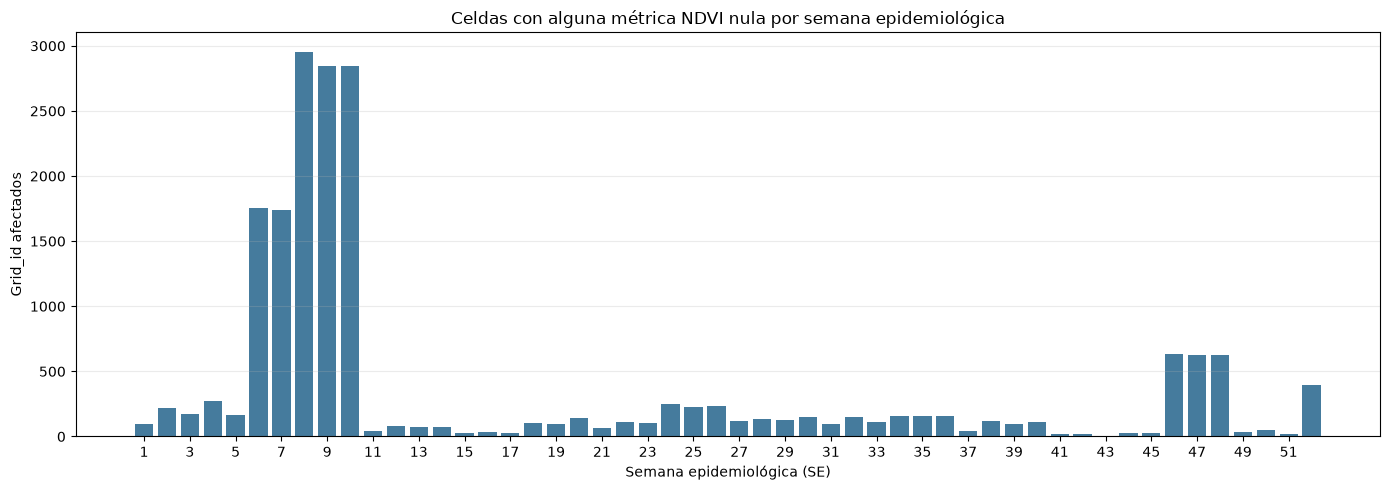

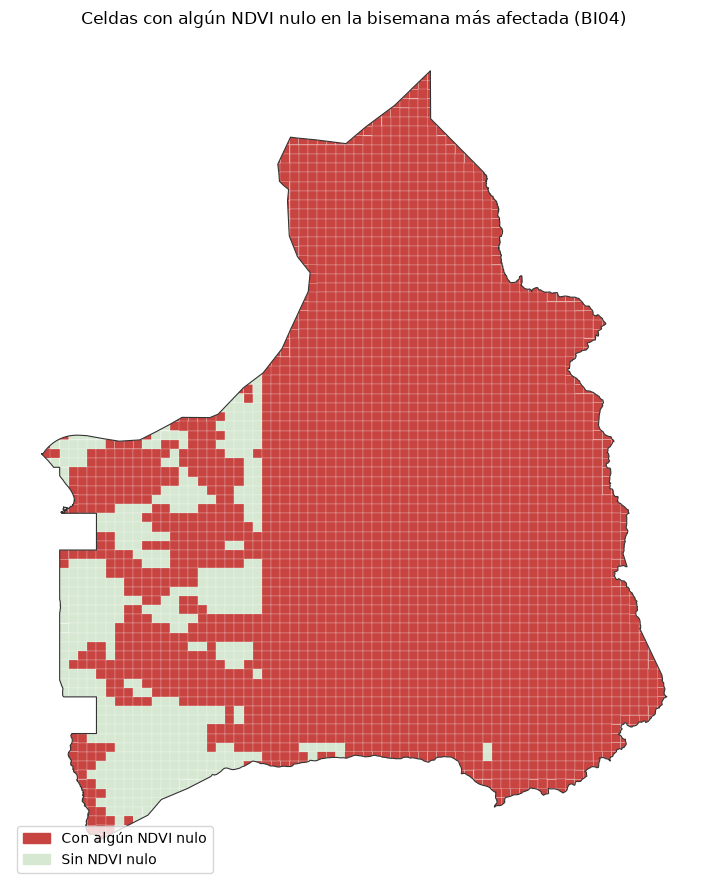

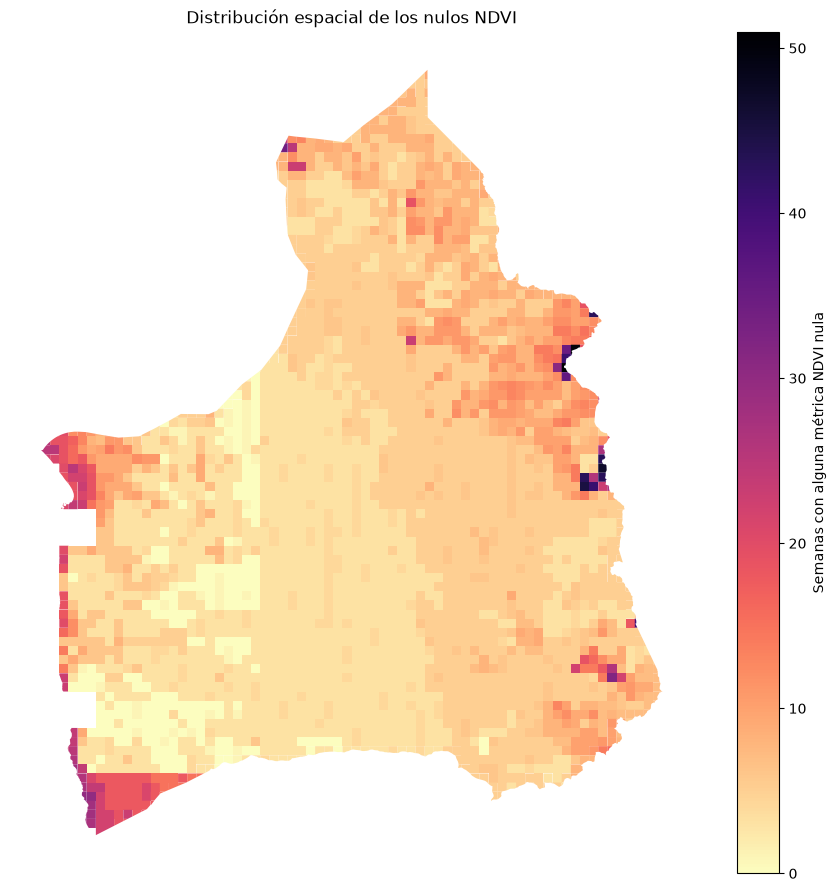

In [6]:
# Distribución temporal de los nulos NDVI por bisemana y semana epidemiológica
ndvi_periods = (
    panel.loc[ndvi_any_null]
    .groupby(["biweek", "epiweek"], as_index=False)
    .agg(grid_id_afectados=("grid_id", "nunique"), filas_ndvi_nulo=("grid_id", "size"))
    .sort_values(["filas_ndvi_nulo", "biweek"], ascending=[False, True])
)
# Distribución espacial: frecuencia de nulos para cada grid_id
ndvi_grid = (
    panel.loc[ndvi_any_null]
    .groupby("grid_id", as_index=False)
    .agg(filas_ndvi_nulo=("grid_id", "size"), bisemanas_afectadas=("biweek", "nunique"), epiweeks_afectadas=("epiweek", "nunique"))
    .sort_values(["filas_ndvi_nulo", "grid_id"], ascending=[False, True])
)
# El gráfico incluye las 52 semanas; las semanas sin casos reciben valor cero
ndvi_periods_plot = (
    ndvi_periods.set_index("epiweek")["grid_id_afectados"]
    .reindex(range(1, 53), fill_value=0)
)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(ndvi_periods_plot.index, ndvi_periods_plot.values, color="#457b9d")
ax.set(
    title="Celdas con alguna métrica NDVI nula por semana epidemiológica",
    xlabel="Semana epidemiológica (SE)",
    ylabel="Grid_id afectados",
)
ax.set_xticks(range(1, 53, 2))
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "ndvi_nulls_by_epiweek.png", dpi=180, bbox_inches="tight")
plt.show()

# Identifica la bisemana con mayor cantidad de grid_id distintos afectados
affected_grids_by_biweek = (
    panel.loc[ndvi_any_null]
    .groupby("biweek")["grid_id"]
    .nunique()
)
relevant_biweek = (
    int(affected_grids_by_biweek.idxmax())
    if not affected_grids_by_biweek.empty
    else None
)
if relevant_biweek is not None:
    # Una celda se marca como afectada si alguna métrica es nula en cualquiera de las dos semanas de la bisemana
    ndvi_map_status = (
        panel.loc[panel["biweek"].eq(relevant_biweek)]
        .assign(sin_ndvi=lambda frame: frame[NDVI_COLUMNS].isna().any(axis=1))
        .groupby("grid_id", as_index=False)["sin_ndvi"]
        .any()
    )
    ndvi_map = grid_geometry.merge(
        ndvi_map_status,
        on="grid_id",
        how="left",
        validate="one_to_one",
    ).fillna({"sin_ndvi": False})
    fig, ax = plt.subplots(figsize=(9, 9))
    ndvi_map.plot(
        ax=ax,
        color=np.where(ndvi_map["sin_ndvi"], "#c74440", "#d7e8d2"),
        edgecolor="white",
        linewidth=0.15,
    )
    ndvi_map.dissolve().boundary.plot(ax=ax, color="#333333", linewidth=0.8)
    ax.legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color="#c74440", label="Con algún NDVI nulo"),
            plt.Rectangle((0, 0), 1, 1, color="#d7e8d2", label="Sin NDVI nulo"),
        ],
        loc="lower left",
    )
    ax.set_title(
        f"Celdas con algún NDVI nulo en la bisemana más afectada (BI{relevant_biweek:02d})"
    )
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(
        FIG_DIR / "ndvi_nulls_most_affected_biweek.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No hay bisemanas con valores NDVI nulos para mapear.")

# Se incorporan también las celdas sin nulos, con valor cero, para representar toda la grilla
ndvi_grid_map = grid_geometry[["grid_id", "geometry"]].merge(
    ndvi_grid[["grid_id", "filas_ndvi_nulo"]],
    on="grid_id",
    how="left",
    validate="one_to_one",
)
ndvi_grid_map["filas_ndvi_nulo"] = (
    ndvi_grid_map["filas_ndvi_nulo"].fillna(0).astype(int)
)
ndvi_grid_map = gpd.GeoDataFrame(
    ndvi_grid_map, geometry="geometry", crs=grid_geometry.crs
)
fig, ax = plt.subplots(figsize=(9, 9))
ndvi_grid_map.plot(
    column="filas_ndvi_nulo",
    cmap="magma_r",
    legend=True,
    linewidth=0,
    legend_kwds={"label": "Semanas con alguna métrica NDVI nula"},
    ax=ax,
)
ax.set_title("Distribución espacial de los nulos NDVI")
ax.axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "ndvi_nulls_spatial_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()


## Sensibilidad a umbrales de cobertura NDVI

Se comparan umbrales de 50, 60, 70, 80 y 90 % usando `*_coverage_pct`. Se toma la primera semana de cada bisemana (`epiweek = 2 × biweek − 1`) para contar cada cobertura una sola vez.

Sensibilidad a umbrales mínimos de cobertura NDVI


,metric,threshold_pct,selected_for_aggregation,cell_biweeks,insufficient_cell_biweeks,insufficient_pct,affected_grid_ids,affected_biweeks
0,ndvi_desvest_bisemanal,50.0,False,88634,5631,6.353092,3022,26
1,ndvi_desvest_bisemanal,60.0,False,88634,6055,6.831464,3071,26
2,ndvi_desvest_bisemanal,70.0,False,88634,6583,7.427172,3116,26
3,ndvi_desvest_bisemanal,80.0,True,88634,7175,8.095088,3167,26
4,ndvi_desvest_bisemanal,90.0,False,88634,8074,9.109371,3228,26
5,ndvi_maximo_bisemanal,50.0,False,88634,5631,6.353092,3022,26
6,ndvi_maximo_bisemanal,60.0,False,88634,6055,6.831464,3071,26
7,ndvi_maximo_bisemanal,70.0,False,88634,6583,7.427172,3116,26
8,ndvi_maximo_bisemanal,80.0,True,88634,7175,8.095088,3167,26
9,ndvi_maximo_bisemanal,90.0,False,88634,8074,9.109371,3228,26


Distribución de la cobertura por métrica y bisemana


,metric,biweek,count,mean,std,min,5%,25%,50%,75%,95%,max
0,ndvi_desvest_bisemanal,1,3409.0,98.078904,10.663252,0.000000,96.179413,100.000000,100.000000,100.000000,100.0,100.0
1,ndvi_desvest_bisemanal,2,3409.0,97.182912,10.599264,0.000000,79.427700,100.000000,100.000000,100.000000,100.0,100.0
2,ndvi_desvest_bisemanal,3,3409.0,96.964881,12.417400,0.000000,81.892285,100.000000,100.000000,100.000000,100.0,100.0
3,ndvi_desvest_bisemanal,4,3409.0,60.968296,40.765947,0.000000,0.000000,15.296217,77.249794,100.000000,100.0,100.0
4,ndvi_desvest_bisemanal,5,3409.0,20.280104,37.175773,0.000000,0.000000,0.000000,0.000000,13.045159,100.0,100.0
5,ndvi_desvest_bisemanal,6,3409.0,99.051329,7.822149,0.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.0
6,ndvi_desvest_bisemanal,7,3409.0,98.660116,8.668413,0.000000,99.635752,100.000000,100.000000,100.000000,100.0,100.0
7,ndvi_desvest_bisemanal,8,3409.0,99.457199,5.351162,0.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.0
8,ndvi_desvest_bisemanal,9,3409.0,99.544049,4.525828,0.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.0
9,ndvi_desvest_bisemanal,10,3409.0,97.633734,13.945003,0.000000,99.167199,100.000000,100.000000,100.000000,100.0,100.0


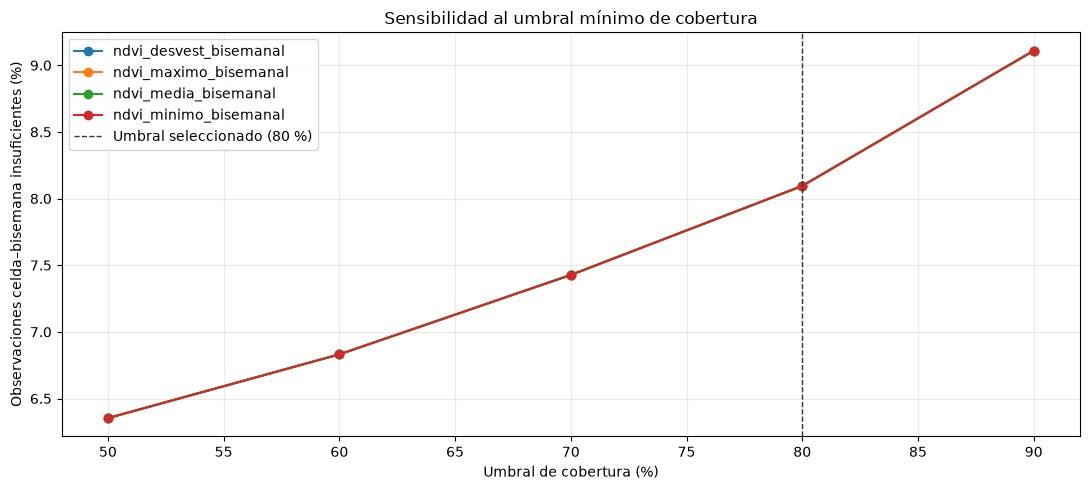

In [7]:
# Umbrales alternativos que se comparan; 80 % es el aplicado por 01
COVERAGE_THRESHOLDS = [50.0, 60.0, 70.0, 80.0, 90.0]
SELECTED_MIN_COVERAGE_PCT = 80.0

# La primera semana conserva la cobertura zonal original de cada bisemana
# y evita contar dos veces la misma medición durante la sensibilidad
first_week_of_biweek = panel["epiweek"].eq(2 * panel["biweek"] - 1)
coverage_source = panel.loc[first_week_of_biweek].copy()
# Las cuatro métricas se llevan a un formato común de cobertura
coverage_parts = []
for metric in NDVI_COLUMNS:
    coverage_column = f"{metric}_coverage_pct"
    pixel_column = f"{metric}_pixel_count"
    total_column = f"{metric}_total_pixel_count"
    # Verifica que 01 haya dejado nulos los valores con cobertura inferior a 80 %
    insufficient_at_selected_threshold = (
        coverage_source[coverage_column].isna()
        | coverage_source[coverage_column].lt(SELECTED_MIN_COVERAGE_PCT)
    )
    if coverage_source.loc[insufficient_at_selected_threshold, metric].notna().any():
        raise ValueError(
            f"{metric} conserva valores con cobertura inferior a {SELECTED_MIN_COVERAGE_PCT:g} %."
        )
    # Se estandarizan los nombres para apilar todas las métricas
    part = coverage_source[["grid_id", "biweek", pixel_column, total_column, coverage_column]].copy()
    part = part.rename(
        columns={
            pixel_column: "valid_pixel_count",
            total_column: "total_pixel_count",
            coverage_column: "coverage_pct",
        }
    )
    part["metric"] = metric
    coverage_parts.append(part)

# Una fila por grid_id, métrica y bisemana
ndvi_grid_biweek_coverage = pd.concat(coverage_parts, ignore_index=True)
ndvi_grid_biweek_coverage["biweek"] = ndvi_grid_biweek_coverage["biweek"].astype(int)
expected_coverage_rows = panel["grid_id"].nunique() * 26 * len(NDVI_COLUMNS)
if len(ndvi_grid_biweek_coverage) != expected_coverage_rows:
    raise ValueError(
        "La tabla de cobertura no tiene una fila por grid_id, métrica y bisemana: "
        f"observadas={len(ndvi_grid_biweek_coverage):,}; esperadas={expected_coverage_rows:,}."
    )
if ndvi_grid_biweek_coverage.duplicated(["grid_id", "metric", "biweek"]).any():
    raise ValueError("La tabla de cobertura contiene llaves grid_id–métrica–bisemana duplicadas.")

# Recuento de observaciones insuficientes bajo cada umbral alternativo
threshold_rows = []
for metric, frame in ndvi_grid_biweek_coverage.groupby("metric"):
    for threshold in COVERAGE_THRESHOLDS:
        insufficient = frame["coverage_pct"].isna() | frame["coverage_pct"].lt(threshold)
        threshold_rows.append(
            {
                "metric": metric,
                "threshold_pct": threshold,
                "selected_for_aggregation": threshold == SELECTED_MIN_COVERAGE_PCT,
                "cell_biweeks": len(frame),
                "insufficient_cell_biweeks": int(insufficient.sum()),
                "insufficient_pct": 100 * insufficient.mean(),
                "affected_grid_ids": int(frame.loc[insufficient, "grid_id"].nunique()),
                "affected_biweeks": int(frame.loc[insufficient, "biweek"].nunique()),
            }
        )

# Resumen de sensibilidad y distribución descriptiva por métrica y bisemana
coverage_threshold_summary = pd.DataFrame(threshold_rows)
coverage_descriptive = (
    ndvi_grid_biweek_coverage.groupby(["metric", "biweek"])["coverage_pct"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .reset_index()
)

# Guardado de tablas reproducibles para análisis posteriores
ndvi_grid_biweek_coverage.to_parquet(
    DIAG_DIR / "ndvi_grid_biweek_coverage.parquet", index=False
)
coverage_threshold_summary.to_csv(
    DIAG_DIR / "ndvi_coverage_threshold_summary.csv", index=False
)
coverage_descriptive.to_csv(
    DIAG_DIR / "ndvi_cell_coverage_by_biweek.csv", index=False
)

print("Sensibilidad a umbrales mínimos de cobertura NDVI")
display(coverage_threshold_summary)
print("Distribución de la cobertura por métrica y bisemana")
display(coverage_descriptive)

# Curvas de sensibilidad: porcentaje insuficiente según el umbral aplicado
fig, ax = plt.subplots(figsize=(11, 5))
for metric, frame in coverage_threshold_summary.groupby("metric"):
    ax.plot(frame["threshold_pct"], frame["insufficient_pct"], marker="o", label=metric)
ax.axvline(SELECTED_MIN_COVERAGE_PCT, color="#333333", linestyle="--", linewidth=1, label="Umbral seleccionado (80 %)")
ax.set(
    title="Sensibilidad al umbral mínimo de cobertura",
    xlabel="Umbral de cobertura (%)",
    ylabel="Observaciones celda–bisemana insuficientes (%)",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "ndvi_coverage_threshold_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()


In [8]:
# El mapa de la bisemana más afectada fue integrado en el diagnóstico NDVI anterior.


## Conclusión reproducible

Se guardan las tablas de cobertura y sensibilidad. La imputación se realiza posteriormente en `03_data_cleaning.ipynb`.

In [9]:
# Resumen final de los principales objetos diagnósticos construidos
print("Nulos por bloque:")
display(group_null_summary)
print("Nulos NDVI por métrica y causa:")
display(ndvi_null_long.query("filas > 0"))
print(f"Celdas afectadas por algún nulo NDVI: {len(ndvi_grid):,}")
print(f"Bisemanas afectadas por algún nulo NDVI: {ndvi_periods['biweek'].nunique() if not ndvi_periods.empty else 0:,}")
print("Sensibilidad de cobertura para el umbral seleccionado:")
display(coverage_threshold_summary.loc[coverage_threshold_summary["selected_for_aggregation"]])
print("Las variables con nulos identificadas deben evaluarse para imputación en data_cleaning.ipynb; aquí no se imputa ninguna.")


Nulos por bloque:


,grupo,columnas,filas_con_algun_nulo,filas_con_todos_nulos,grid_id_afectados,epiweeks_afectadas
0,temporal,"year, epiweek, biweek",0,0,0,0
1,clima,"tmean_c, tmin_c, tmax_c, rh_mean, rh_min, rh_m...",0,0,0,0
2,altitud,"alt_min, alt_mean, alt_max",260,260,5,52
3,población_contexto,"population, koppen_fin",0,0,0,0
4,NDVI,"ndvi_media_bisemanal, ndvi_media_bisemanal_pix...",18976,0,3210,52


Nulos NDVI por métrica y causa:


,metrica,causa,filas,grid_id_afectados,bisemanas_afectadas,epiweeks_afectadas
0,ndvi_media_bisemanal,valor_nulo,18976,3210,26,52
1,ndvi_media_bisemanal,pixel_count_igual_cero,9365,2572,23,45
2,ndvi_media_bisemanal,sin_pixeles_NDVI_validos_dentro_del_grid_id,9365,2572,23,45
7,ndvi_maximo_bisemanal,valor_nulo,18976,3210,26,52
8,ndvi_maximo_bisemanal,pixel_count_igual_cero,9365,2572,23,45
9,ndvi_maximo_bisemanal,sin_pixeles_NDVI_validos_dentro_del_grid_id,9365,2572,23,45
14,ndvi_minimo_bisemanal,valor_nulo,18976,3210,26,52
15,ndvi_minimo_bisemanal,pixel_count_igual_cero,9365,2572,23,45
16,ndvi_minimo_bisemanal,sin_pixeles_NDVI_validos_dentro_del_grid_id,9365,2572,23,45
21,ndvi_desvest_bisemanal,valor_nulo,18976,3210,26,52


Celdas afectadas por algún nulo NDVI: 3,210
Bisemanas afectadas por algún nulo NDVI: 26
Sensibilidad de cobertura para el umbral seleccionado:


,metric,threshold_pct,selected_for_aggregation,cell_biweeks,insufficient_cell_biweeks,insufficient_pct,affected_grid_ids,affected_biweeks
3,ndvi_desvest_bisemanal,80.0,True,88634,7175,8.095088,3167,26
8,ndvi_maximo_bisemanal,80.0,True,88634,7175,8.095088,3167,26
13,ndvi_media_bisemanal,80.0,True,88634,7175,8.095088,3167,26
18,ndvi_minimo_bisemanal,80.0,True,88634,7175,8.095088,3167,26


Las variables con nulos identificadas deben evaluarse para imputación en data_cleaning.ipynb; aquí no se imputa ninguna.
